In [1]:
# Social Network Ads Purchase Prediction using Support Vector Classification
# Author: Manikandaprabhu.S
# Objective: Predict whether a user will purchase a product based on Age, Estimated Salary, and Gender.

In [2]:
## 1. Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
## 3. Exploring the Dataset
data = pd.get_dummies(dataset,"Gender",dtype = int)
## 4. Handling Categorical Variables (Gender Encoding)
d = data.drop(["User ID","Gender_Female"], axis=1)
d

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1
...,...,...,...,...
395,46,41000,1,0
396,51,23000,1,1
397,50,20000,1,0
398,36,33000,0,1


In [5]:
## 5. Checking Dataset Information
d["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [6]:
d.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [7]:
## 6. Preparing Features and Target Variable
Features = d[['Age', 'EstimatedSalary', 'Gender_Male']]
Target = d["Purchased"]

In [8]:
## 7. Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(Features,Target,test_size=1/3,random_state=0)

In [9]:
## 8. Feature Scaling (Important for SVC)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
## 9. Training SVC Model with Hyperparameter Tuning (GridSearchCV)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {'kernel':['linear','rbf','poly','sigmoid'],
             'gamma':['auto','scale'],
             'C':[10,100,1000,2000,3000]} 



grid_model = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
## 10. fitting the model for grid search 
grid_model.fit(X_train, Y_train) 

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,SVC()
,param_grid,"{'C': [10, 100, ...], 'gamma': ['auto', 'scale'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [11]:
## 11. print best parameter after tuning 
print("The R_score value for best parameter {}:".format(grid_model.best_params_))

The R_score value for best parameter {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}:


In [12]:

re=grid_model.cv_results_
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008060,0.001741,0.009728,0.002059,10,auto,linear,"{'C': 10, 'gamma': 'auto', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,21
1,0.005596,0.000617,0.009075,0.002362,10,auto,rbf,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
2,0.006871,0.000966,0.010653,0.001293,10,auto,poly,"{'C': 10, 'gamma': 'auto', 'kernel': 'poly'}",0.799620,0.808392,0.787943,0.924528,0.901744,0.844445,0.056918,11
3,0.005175,0.001090,0.007652,0.001363,10,auto,sigmoid,"{'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}",0.762677,0.738916,0.655795,0.796284,0.766556,0.744045,0.047743,39
4,0.006587,0.001259,0.007107,0.001663,10,scale,linear,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,21
5,0.004461,0.000724,0.008439,0.001936,10,scale,rbf,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.867478,0.886792,0.869709,0.944161,0.943041,0.902236,0.034431,3
6,0.006585,0.000702,0.006490,0.000971,10,scale,poly,"{'C': 10, 'gamma': 'scale', 'kernel': 'poly'}",0.799620,0.808392,0.787943,0.924528,0.901744,0.844445,0.056918,11
7,0.004488,0.000833,0.006700,0.001134,10,scale,sigmoid,"{'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.762677,0.738916,0.753180,0.778067,0.766556,0.759879,0.013172,31
8,0.012318,0.002281,0.004782,0.001101,100,auto,linear,"{'C': 100, 'gamma': 'auto', 'kernel': 'linear'}",0.776290,0.790949,0.698235,0.923510,0.901744,0.818146,0.083619,21
9,0.005004,0.001464,0.006837,0.001386,100,auto,rbf,"{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}",0.867478,0.886792,0.870362,0.944161,0.943041,0.902367,0.034308,1


In [13]:

y_pred = grid_model.predict(X_test) 

In [14]:
## 12. Evaluating the Model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
cm

array([[80,  5],
       [ 7, 42]])

In [15]:
## 13. Confusion Matrix
from sklearn.metrics import classification_report
clf_report = classification_report(Y_test, y_pred)
print(clf_report)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        85
           1       0.89      0.86      0.88        49

    accuracy                           0.91       134
   macro avg       0.91      0.90      0.90       134
weighted avg       0.91      0.91      0.91       134



In [16]:
grid_model.predict([[46,41000,0]])

array([1])

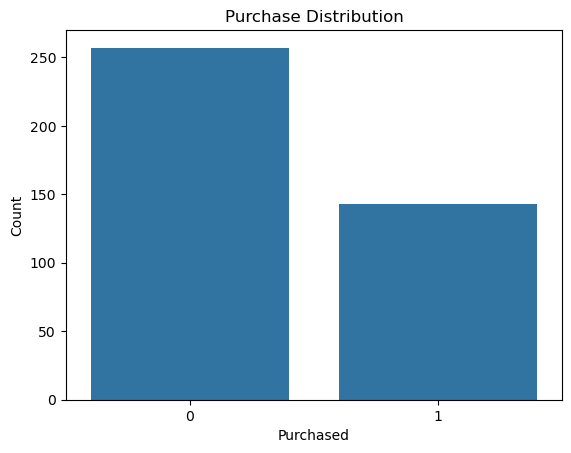

In [17]:
## 14. Visualizing Model Performance
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Purchased', data=d)

plt.title('Purchase Distribution')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()

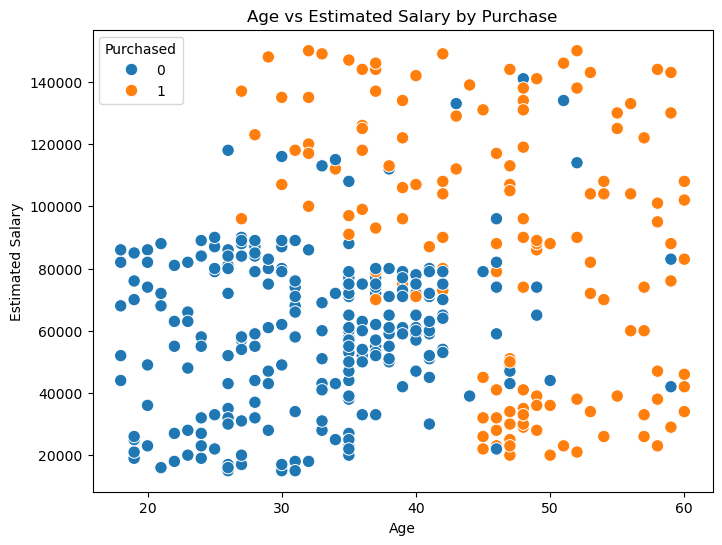

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=d,
    s=80
)

plt.title('Age vs Estimated Salary by Purchase')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

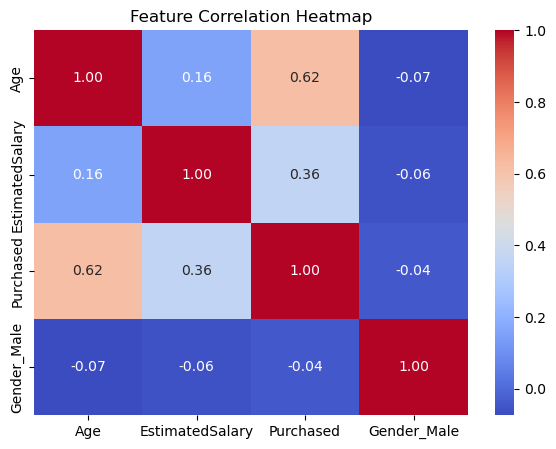

In [19]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    d.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
## 15. Saving the Trained Model
import pickle
filename = "Finalized_model.sav"
save_model = pickle.dump(grid_model, open(filename, 'wb'))